## 1. Import thư viện và Load dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import os

sns.set_style('whitegrid')

current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)

train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}")

## 2. Feature Engineering & Chuẩn bị biến
Chia các biến số (Numerical) và biến phân loại (Categorical). Dùng get_dummies cho địa điểm và áp dụng PolynomialFeatures (bậc 2) cho các biến số nhằm bắt lấy các mối quan hệ phi tuyến tính.

In [ ]:
# Các features
features_num = ['dien_tich_log', 'phong_ngu', 'phong_tam', 'so_tang']
features_cat = ['quan', 'thanh_pho', 'phap_ly']

y_train = train_df['gia_log']
y_test_original = test_df['gia']

X_train_num = train_df[features_num]
X_test_num = test_df[features_num]

X_train_cat = pd.get_dummies(train_df[features_cat], drop_first=True)
X_test_cat = pd.get_dummies(test_df[features_cat], drop_first=True)

# Đồng bộ cột
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

# Polynomial (chỉ các cột num)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_num)
X_test_poly = poly.transform(X_test_num)



Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)
Số features sau khi combine: 48
Intercept: -0.0638
Hiệu suất model 3


,Metric,Value
0,R2,0.7369
1,MAE,2.7082
2,MSE,26.1337
3,RMSE,5.1121


## 3. Huấn luyện mô hình (Training), dự báo và đánh giá hiệu suất

In [ ]:
# Kết hơpk
X_train = np.hstack([X_train_poly, X_train_cat.values])
X_test = np.hstack([X_test_poly, X_test_cat.values])

print(f"Số features sau khi combine: {X_train.shape[1]}")

# Train
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")

# Prediction
y_pred_log = model.predict(X_test)
y_pred_original = np.expm1(y_pred_log)

# Evaluation
r2 = r2_score(test_df['gia_log'], y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

results = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'MSE', 'RMSE'],
    'Value': [f"{r2:.4f}", f"{mae:.4f}", f"{mse:.4f}", f"{rmse:.4f}"]
})

print("Hiệu suất model 3")
display(results)

## 4. Trực quan hóa kết quả (Visualization)

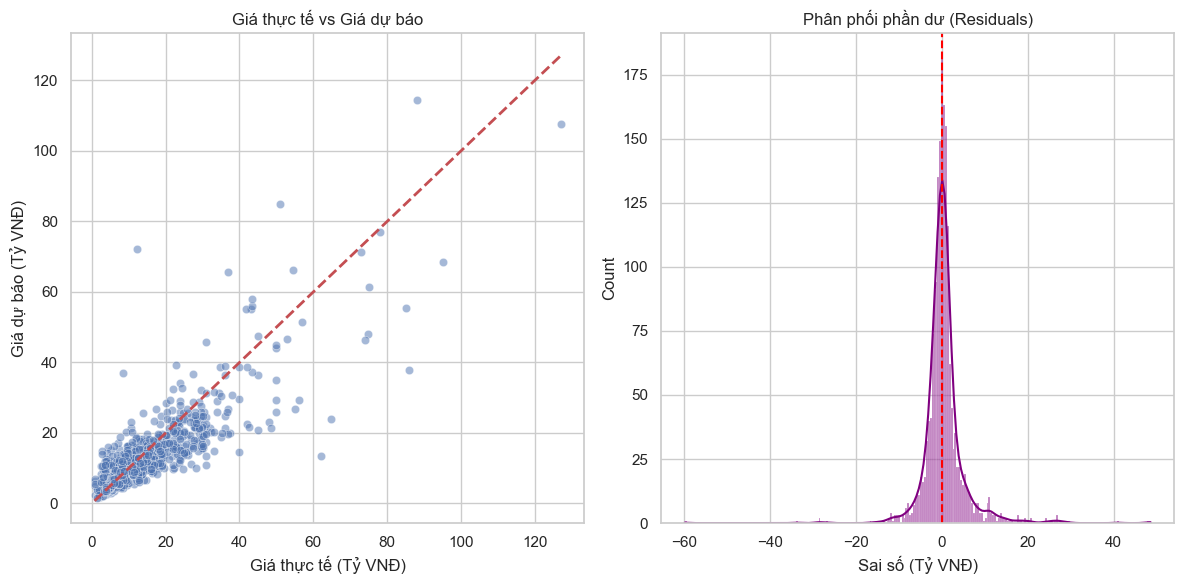

In [19]:
# Visualisation
plt.figure(figsize=(12, 6))

residuals = y_test_original - y_pred_original

# Scatter plot 
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5)

plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2)

plt.title("Giá thực tế vs Giá dự báo")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự báo (Tỷ VNĐ)")

# Residual 
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')

plt.title("Phân phối phần dư (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")

plt.tight_layout()
plt.show()

## Nhận xét về biểu đồ
Giá thực tế vs Dự báo: Các điểm tập trung khá dày quanh đường 45 độ ở phân khúc giá thấp (0 - 20 tỷ), chứng tỏ model học tốt ở tầm giá này. Tuy nhiên, ở phân khúc giá cao (trên 40 tỷ), các điểm bắt đầu "bay" lung tung, cho thấy model chưa nắm bắt được đặc điểm của nhà cao cấp.

Phân phối phần dư (Residuals): Biểu đồ hình chuông khá cân đối và tập trung quanh vạch 0, đây là tín hiệu tốt cho thấy sai số có tính ngẫu nhiên (không bị bias quá nặng). Tuy nhiên, vẫn có những "đuôi" dài về hai phía (sai số lên tới 40-60 tỷ), củng cố thêm nhận định về outliers.

In [20]:
print(f"Model: Polynomial Regression + Location Features")
print(f"R2: {r2:.4f} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")

Model: Polynomial Regression + Location Features
R2: 0.7369 | MAE: 2.7082 | MSE: 26.1337 | RMSE: 5.1121


## Nhận xét về chỉ số
Độ giải thích ($R^2 = 0.7369$): Mô hình giải thích được khoảng 74% sự biến động của giá nhà.

Sai số dự báo (MAE = 2.7082): Trung bình mỗi căn nhà dự báo lệch khoảng 2.7 tỷ VNĐ. Đây là con số cần lưu ý, vì với các căn hộ giá rẻ (dưới 5-7 tỷ), mức sai số này là khá lớn.

RMSE (5.1121) cao hơn hẳn MAE: Điều này cho thấy trong dữ liệu có nhiều outliers (điểm dữ liệu ngoại lai) hoặc các căn nhà siêu sang làm sai số bị đội lên rất mạnh (vì RMSE phạt nặng các sai số lớn).